In [1]:
!pip install -q import-ipynb  

import sys
import os

project_root = '/content/document-classifier'
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to sys.path")

import import_ipynb
from src.utils.connect_to_colab import setup_colab_environment

vm_path = setup_colab_environment()
print(f"\nProject VM path: {vm_path}")

# Quick checks
print("Drive mounted?", os.path.ismount('/content/drive'))
print("Data symlink exists?", os.path.islink(f"{vm_path}/data"))
print("Models symlink exists?", os.path.islink(f"{vm_path}/src/models/trained_models"))

Added /content/document-classifier to sys.path
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
Already up to date.
Setup complete!

Project VM path: /content/document-classifier
Drive mounted? True
Data symlink exists? True
Models symlink exists? True


In [2]:
#Define clean dataset path + existence check

images_root = "/content/document-classifier/data/scanned_docs"

print("Dataset path:", images_root)

if os.path.exists(images_root):
    class_folders = [d for d in os.listdir(images_root) if os.path.isdir(os.path.join(images_root, d))]
    print(f"Found {len(class_folders)} class folders")
    print("First few classes:", class_folders[:5])
    print("Path is symlink?", os.path.islink(images_root))
else:
    print("ERROR: Dataset folder not found!")
    print("→ Check if download/copy/symlink worked in previous cells")

Dataset path: /content/document-classifier/data/scanned_docs
Found 10 class folders
First few classes: ['ADVE', 'Email', 'Form', 'Letter', 'News']
Path is symlink? False


In [3]:
# Here we will define our image transforms

from torchvision import transforms

IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),      # Repeat grayscale to 3 channels for pretrained models
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = train_transform

print("Training transform:", train_transform)


Training transform: Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


Total images loaded: 3482
Number of classes: 10
['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']

Class name to numeric index mapping:
{'ADVE': 0, 'Email': 1, 'Form': 2, 'Letter': 3, 'Memo': 4, 'News': 5, 'Note': 6, 'Report': 7, 'Resume': 8, 'Scientific': 9}


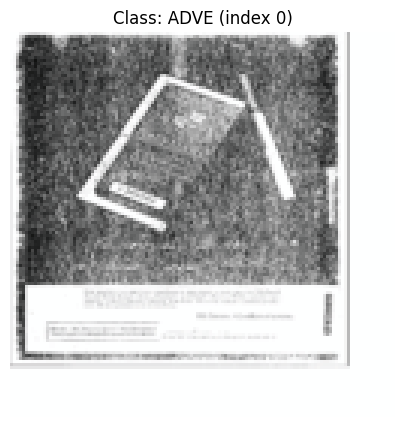

In [4]:
# Load full dataset with ImageFolder
import torch
import numpy as np
from torchvision import datasets
import matplotlib.pyplot as plt

images_root = "/content/document-classifier/data/scanned_docs"

full_dataset = datasets.ImageFolder(
    root=images_root,
    transform=train_transform  
)

print(f"Total images loaded: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")
print(full_dataset.classes)

print("\nClass name to numeric index mapping:")
print(full_dataset.class_to_idx)

# Show the first sample as example
first_image_tensor, first_label = full_dataset[0]
img = first_image_tensor.permute(1, 2, 0).cpu().numpy()

# Denormalize using NumPy arrays 
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img = (img * std + mean).clip(0, 1)

# Plot
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f"Class: {full_dataset.classes[first_label]} (index {first_label})")
plt.show()

In [5]:
# Split dataset into train / val / test 
from torch.utils.data import random_split

torch.manual_seed(42)  
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)
test_size  = total_size - train_size - val_size

print(f"  Train: {train_size} images (~80%)")
print(f"  Val:   {val_size} images (~10%)")
print(f"  Test:  {test_size} images (~10%)")

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

  Train: 2785 images (~80%)
  Val:   348 images (~10%)
  Test:  349 images (~10%)
Train dataset: 2785 samples
Val dataset:   348 samples
Test dataset:  349 samples


In [6]:
# Create DataLoaders
from torch.utils.data import DataLoader


batch_size = 32
num_workers = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,          
    num_workers=num_workers,
    pin_memory=True,        # Faster transfer to GPU
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}  ({len(train_dataset)} samples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_dataset)} samples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_dataset)} samples)")

#Show shapes of one batch 
images, labels = next(iter(train_loader))
print(f"Image shape: {images.shape}")   
print(f"Labels shape: {labels.shape}")   

Train batches: 87  (2785 samples)
Val batches:   11  (348 samples)
Test batches:  11  (349 samples)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
